## Cryptocurrency Volatility Prediction

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## Step 1 :  Data Preprocessing and Scaling

In [102]:
df = pd.read_csv('/content/dataset.csv.zip')

In [103]:
df

,Unnamed: 0,open,high,low,close,volume,marketCap,timestamp,crypto_name,date
0,0,112.900002,118.800003,107.142998,115.910004,0.000000e+00,1.288693e+09,2013-05-05T23:59:59.999Z,Bitcoin,2013-05-05
1,1,3.493130,3.692460,3.346060,3.590890,0.000000e+00,6.229819e+07,2013-05-05T23:59:59.999Z,Litecoin,2013-05-05
2,2,115.980003,124.663002,106.639999,112.300003,0.000000e+00,1.249023e+09,2013-05-06T23:59:59.999Z,Bitcoin,2013-05-06
3,3,3.594220,3.781020,3.116020,3.371250,0.000000e+00,5.859436e+07,2013-05-06T23:59:59.999Z,Litecoin,2013-05-06
4,4,112.250000,113.444000,97.699997,111.500000,0.000000e+00,1.240594e+09,2013-05-07T23:59:59.999Z,Bitcoin,2013-05-07
...,...,...,...,...,...,...,...,...,...,...
72941,72941,0.022604,0.022988,0.022197,0.022796,4.040134e+07,1.652957e+09,2022-10-23T23:59:59.999Z,VeChain,2022-10-23
72942,72942,1.468244,1.530464,1.435415,1.517878,2.844351e+07,1.572825e+09,2022-10-23T23:59:59.999Z,Flow,2022-10-23
72943,72943,4.950431,5.148565,4.945280,5.117206,1.069497e+08,1.559551e+09,2022-10-23T23:59:59.999Z,Filecoin,2022-10-23
72944,72944,0.000233,0.000243,0.000226,0.000239,2.143268e+08,1.576291e+09,2022-10-23T23:59:59.999Z,Terra Classic,2022-10-23


In [104]:
df.head()

,Unnamed: 0,open,high,low,close,volume,marketCap,timestamp,crypto_name,date
0,0,112.900002,118.800003,107.142998,115.910004,0.0,1.288693e+09,2013-05-05T23:59:59.999Z,Bitcoin,2013-05-05
1,1,3.493130,3.692460,3.346060,3.590890,0.0,6.229819e+07,2013-05-05T23:59:59.999Z,Litecoin,2013-05-05
2,2,115.980003,124.663002,106.639999,112.300003,0.0,1.249023e+09,2013-05-06T23:59:59.999Z,Bitcoin,2013-05-06
3,3,3.594220,3.781020,3.116020,3.371250,0.0,5.859436e+07,2013-05-06T23:59:59.999Z,Litecoin,2013-05-06
4,4,112.250000,113.444000,97.699997,111.500000,0.0,1.240594e+09,2013-05-07T23:59:59.999Z,Bitcoin,2013-05-07


In [105]:
df.tail()

,Unnamed: 0,open,high,low,close,volume,marketCap,timestamp,crypto_name,date
72941,72941,0.022604,0.022988,0.022197,0.022796,4.040134e+07,1.652957e+09,2022-10-23T23:59:59.999Z,VeChain,2022-10-23
72942,72942,1.468244,1.530464,1.435415,1.517878,2.844351e+07,1.572825e+09,2022-10-23T23:59:59.999Z,Flow,2022-10-23
72943,72943,4.950431,5.148565,4.945280,5.117206,1.069497e+08,1.559551e+09,2022-10-23T23:59:59.999Z,Filecoin,2022-10-23
72944,72944,0.000233,0.000243,0.000226,0.000239,2.143268e+08,1.576291e+09,2022-10-23T23:59:59.999Z,Terra Classic,2022-10-23
72945,72945,0.465490,0.471006,0.453438,0.469033,9.509743e+08,2.339868e+10,2022-10-23T23:59:59.999Z,XRP,2022-10-23


In [106]:
df.shape

(72946, 10)

In [107]:
df.dtypes

,0
Unnamed: 0,int64
open,float64
high,float64
low,float64
close,float64
volume,float64
marketCap,float64
timestamp,object
crypto_name,object
date,object


In [108]:
df.columns

Index(['Unnamed: 0', 'open', 'high', 'low', 'close', 'volume', 'marketCap',
       'timestamp', 'crypto_name', 'date'],
      dtype='object')

In [109]:
df.isnull().sum() # There is no null value here

,0
Unnamed: 0,0
open,0
high,0
low,0
close,0
volume,0
marketCap,0
timestamp,0
crypto_name,0
date,0


In [110]:
# For converting the date column into datetime. (Because it's showing this object)
df['date'] = pd.to_datetime(df['date'])


# sort the values by name
df = df.sort_values(by=['crypto_name', 'date']).reset_index(drop=True)

In [111]:
df

,Unnamed: 0,open,high,low,close,volume,marketCap,timestamp,crypto_name,date
0,44644,0.000000,0.516571,0.000000,0.516571,0.000000e+00,0.000000e+00,2020-10-02T23:59:59.999Z,Aave,2020-10-02
1,44709,0.523836,65.305938,0.523801,53.151488,0.000000e+00,0.000000e+00,2020-10-03T23:59:59.999Z,Aave,2020-10-03
2,44780,53.179858,55.070355,50.688990,52.675035,0.000000e+00,0.000000e+00,2020-10-04T23:59:59.999Z,Aave,2020-10-04
3,44826,52.675035,55.112358,49.787900,53.219243,0.000000e+00,8.912813e+07,2020-10-05T23:59:59.999Z,Aave,2020-10-05
4,44843,53.291969,53.402270,40.734578,42.401599,5.830915e+05,7.101144e+07,2020-10-06T23:59:59.999Z,Aave,2020-10-06
...,...,...,...,...,...,...,...,...,...,...
72941,72716,0.488732,0.518314,0.478734,0.492627,3.422192e+09,2.455686e+10,2022-09-25T23:59:59.999Z,XRP,2022-09-25
72942,72768,0.475119,0.477434,0.448158,0.448850,1.524149e+09,2.239791e+10,2022-10-02T23:59:59.999Z,XRP,2022-10-02
72943,72806,0.517149,0.541416,0.508167,0.534061,1.789207e+09,2.662750e+10,2022-10-09T23:59:59.999Z,XRP,2022-10-09
72944,72859,0.481530,0.487103,0.471813,0.477010,1.028960e+09,2.383341e+10,2022-10-16T23:59:59.999Z,XRP,2022-10-16


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72946 entries, 0 to 72945
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Unnamed: 0   72946 non-null  int64         
 1   open         72946 non-null  float64       
 2   high         72946 non-null  float64       
 3   low          72946 non-null  float64       
 4   close        72946 non-null  float64       
 5   volume       72946 non-null  float64       
 6   marketCap    72946 non-null  float64       
 7   timestamp    72946 non-null  object        
 8   crypto_name  72946 non-null  object        
 9   date         72946 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(6), int64(1), object(2)
memory usage: 5.6+ MB


In [113]:
# We are dropping the timestamp column because we have a exact time column name date.
df.drop('timestamp', axis=1, inplace=True)

In [114]:
df

,Unnamed: 0,open,high,low,close,volume,marketCap,crypto_name,date
0,44644,0.000000,0.516571,0.000000,0.516571,0.000000e+00,0.000000e+00,Aave,2020-10-02
1,44709,0.523836,65.305938,0.523801,53.151488,0.000000e+00,0.000000e+00,Aave,2020-10-03
2,44780,53.179858,55.070355,50.688990,52.675035,0.000000e+00,0.000000e+00,Aave,2020-10-04
3,44826,52.675035,55.112358,49.787900,53.219243,0.000000e+00,8.912813e+07,Aave,2020-10-05
4,44843,53.291969,53.402270,40.734578,42.401599,5.830915e+05,7.101144e+07,Aave,2020-10-06
...,...,...,...,...,...,...,...,...,...
72941,72716,0.488732,0.518314,0.478734,0.492627,3.422192e+09,2.455686e+10,XRP,2022-09-25
72942,72768,0.475119,0.477434,0.448158,0.448850,1.524149e+09,2.239791e+10,XRP,2022-10-02
72943,72806,0.517149,0.541416,0.508167,0.534061,1.789207e+09,2.662750e+10,XRP,2022-10-09
72944,72859,0.481530,0.487103,0.471813,0.477010,1.028960e+09,2.383341e+10,XRP,2022-10-16


In [115]:
df.dtypes

,0
Unnamed: 0,int64
open,float64
high,float64
low,float64
close,float64
volume,float64
marketCap,float64
crypto_name,object
date,datetime64[ns]


scaling : scaling will do our large values in between the 0 and 1 like price, voulume, and marketCap.

In [116]:
df_cleaned = df.drop(columns = ['Unnamed: 0'], errors = 'ignore')

In [117]:
# The columns which we want to scale
num_cols = ['open', 'high', 'low', 'close', 'volume', 'marketCap']

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_cleaned[num_cols] = scaler.fit_transform(df[num_cols])

df_cleaned.head()

# We do scaling for Model's accurate and  fast training

,open,high,low,close,volume,marketCap,crypto_name,date
0,0.000000,0.000003,0.000000,0.000008,0.000000,0.000000,Aave,2020-10-02
1,0.000008,0.000403,0.000008,0.000787,0.000000,0.000000,Aave,2020-10-03
2,0.000787,0.000340,0.000763,0.000780,0.000000,0.000000,Aave,2020-10-04
3,0.000780,0.000340,0.000749,0.000788,0.000000,0.000070,Aave,2020-10-05
4,0.000789,0.000329,0.000613,0.000628,0.000002,0.000056,Aave,2020-10-06


## Step 2 : EDA (Exploratory Data Analysis)

In [118]:
# Daily return for each crypto
df['daily_return'] = df.groupby('crypto_name')['close'].pct_change()

In [119]:
# Making valatility of rolling standard deviatioon for last 7 days
df['volatility_7d'] = df.groupby('crypto_name')['daily_return'].transform(lambda x: x.rolling(window=7).std())

In [120]:
df

,Unnamed: 0,open,high,low,close,volume,marketCap,crypto_name,date,daily_return,volatility_7d
0,44644,0.000000,0.516571,0.000000,0.516571,0.000000e+00,0.000000e+00,Aave,2020-10-02,NaN,NaN
1,44709,0.523836,65.305938,0.523801,53.151488,0.000000e+00,0.000000e+00,Aave,2020-10-03,101.892809,NaN
2,44780,53.179858,55.070355,50.688990,52.675035,0.000000e+00,0.000000e+00,Aave,2020-10-04,-0.008964,NaN
3,44826,52.675035,55.112358,49.787900,53.219243,0.000000e+00,8.912813e+07,Aave,2020-10-05,0.010331,NaN
4,44843,53.291969,53.402270,40.734578,42.401599,5.830915e+05,7.101144e+07,Aave,2020-10-06,-0.203266,NaN
...,...,...,...,...,...,...,...,...,...,...,...
72941,72716,0.488732,0.518314,0.478734,0.492627,3.422192e+09,2.455686e+10,XRP,2022-09-25,0.272698,0.099586
72942,72768,0.475119,0.477434,0.448158,0.448850,1.524149e+09,2.239791e+10,XRP,2022-10-02,-0.088865,0.112896
72943,72806,0.517149,0.541416,0.508167,0.534061,1.789207e+09,2.662750e+10,XRP,2022-10-09,0.189842,0.121977
72944,72859,0.481530,0.487103,0.471813,0.477010,1.028960e+09,2.383341e+10,XRP,2022-10-16,-0.106824,0.140350


In [121]:
df.dropna(inplace=True)

In [122]:
df[['crypto_name', 'date', 'close', 'daily_return', 'volatility_7d']].head(10)

,crypto_name,date,close,daily_return,volatility_7d
7,Aave,2020-10-09,46.817744,0.069766,38.517966
8,Aave,2020-10-10,49.133718,0.049468,0.099951
9,Aave,2020-10-11,49.660726,0.010726,0.100147
10,Aave,2020-10-12,52.238692,0.051912,0.102326
11,Aave,2020-10-13,51.124317,-0.021332,0.052304
12,Aave,2020-10-14,51.316518,0.003759,0.040111
13,Aave,2020-10-15,44.019183,-0.142202,0.071584
14,Aave,2020-10-16,39.495844,-0.102758,0.074470
15,Aave,2020-10-17,41.366993,0.047376,0.074141
16,Aave,2020-10-18,40.746972,-0.014988,0.072888


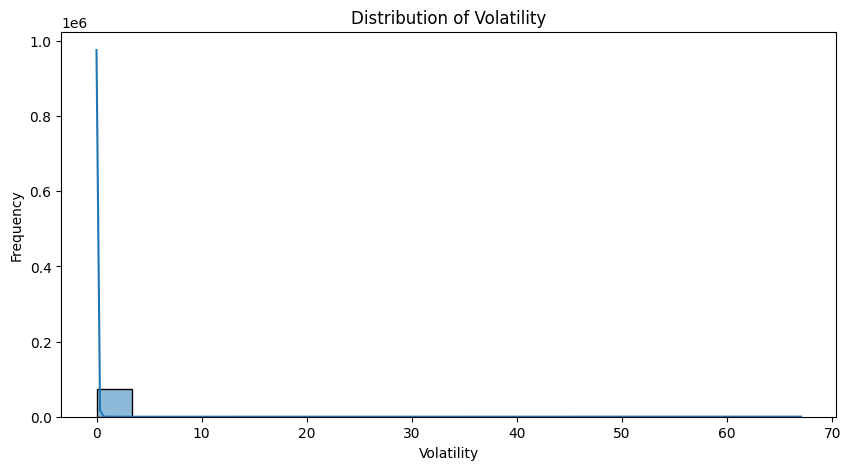

In [123]:
# Univariate Analysis (Distribution of volatility )
plt.figure(figsize=(10,5))
sns.histplot(df['volatility_7d'], bins=20, kde=True)
plt.title('Distribution of Volatility')
plt.xlabel('Volatility')
plt.ylabel('Frequency')
plt.show()

Highly Right Skewed Data : 95% percent of the days in the cypto market there is high volatilty . less or normal in between the (from o to 2-3)

--- Dataset Summary Statistics ---
               open          high           low         close        volume  \
count  72946.000000  72946.000000  72946.000000  72946.000000  72946.000000   
mean       0.012882      0.005527      0.012701      0.012895      0.006290   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.000002      0.000001      0.000002      0.000002      0.000024   
50%        0.000024      0.000011      0.000023      0.000024      0.000313   
75%        0.000386      0.000170      0.000373      0.000389      0.001907   
max        1.000000      1.000000      1.000000      1.000000      1.000000   
std        0.077449      0.033286      0.076429      0.077486      0.027404   

          marketCap                           date  
count  72946.000000                          72946  
mean       0.011570  2019-10-13 03:20:59.945713152  
min        0.000000            2013-05-05 00:00:00  
25%        0.000146            2018-09-08

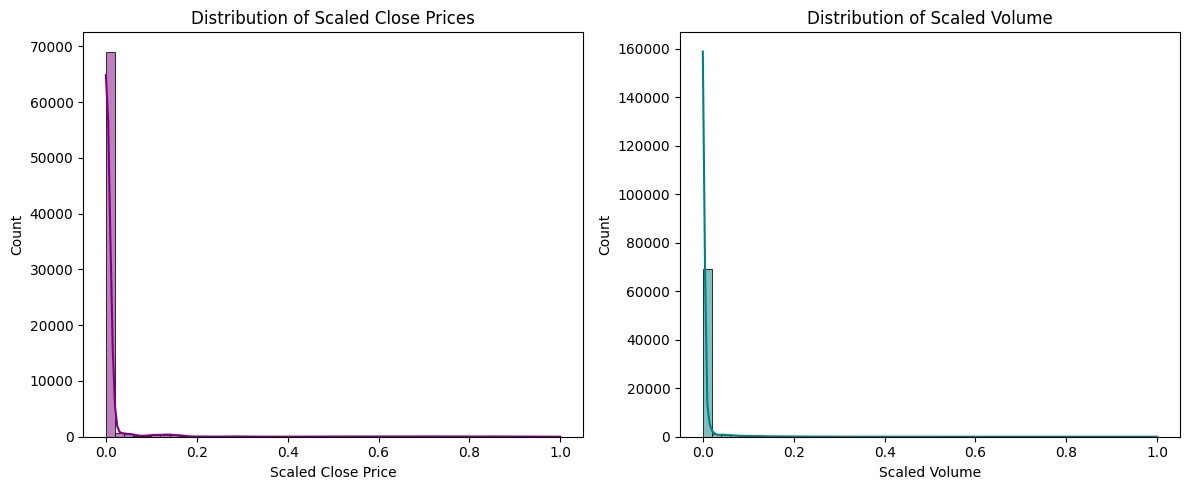

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data ka statistical overview (Mean, Median, Min, Max)
print("--- Dataset Summary Statistics ---")
print(df_cleaned.describe())

# 2. Close Price ka Distribution Plot (Histogram)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_cleaned['close'], bins=50, kde=True, color='purple')
plt.title('Distribution of Scaled Close Prices')
plt.xlabel('Scaled Close Price')

# 3. Volume ka Distribution Plot
plt.subplot(1, 2, 2)
sns.histplot(df_cleaned['volume'], bins=50, kde=True, color='teal')
plt.title('Distribution of Scaled Volume')
plt.xlabel('Scaled Volume')

plt.tight_layout()
plt.show()

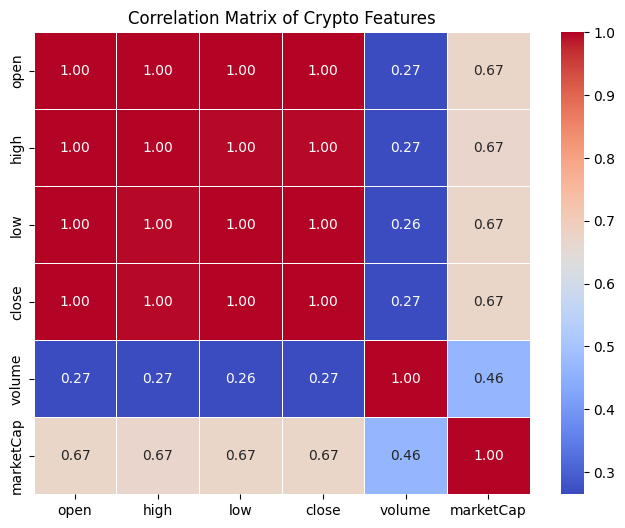

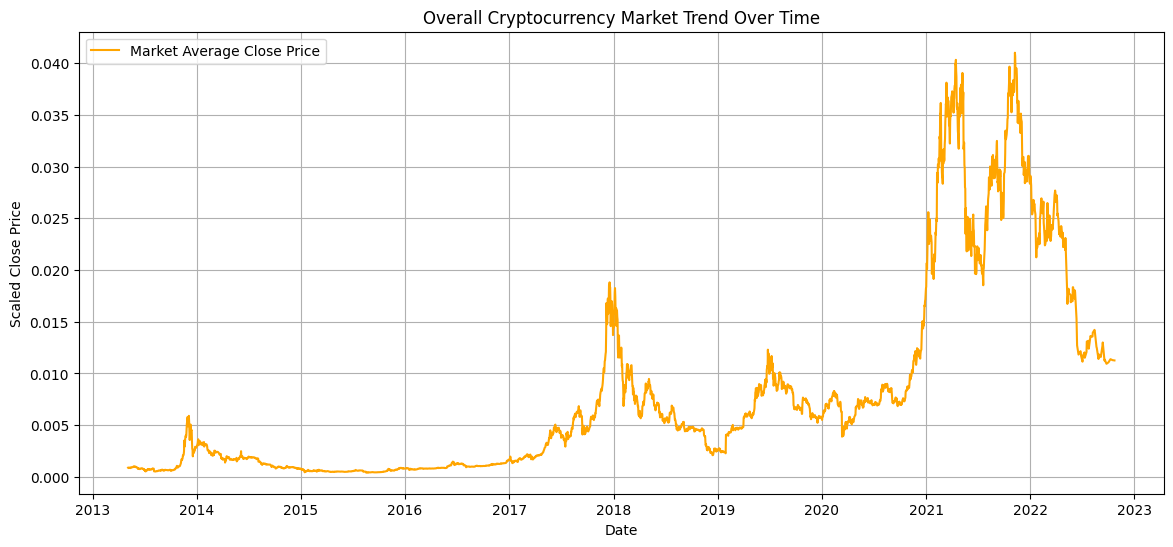

In [130]:
# Multivariate Analysis
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CORRELATION: Features ke aapas ka rishta dekhne ke liye (Heatmap)
plt.figure(figsize=(8, 6))
# Kali numerical columns ka correlation nikalenge
correlation_matrix = df_cleaned[['open', 'high', 'low', 'close', 'volume', 'marketCap']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Crypto Features')
plt.show()

# 2. TRENDS: Time ke sath price kaise change ho raha hai (Time-Series Plot)
# Kyunki dataset me 50+ cryptos hain, hum poore market ka daily average trend dekhenge
plt.figure(figsize=(14, 6))
df_market_trend = df_cleaned.groupby('date')['close'].mean().reset_index()

sns.lineplot(data=df_market_trend, x='date', y='close', color='orange', label='Market Average Close Price')
plt.title('Overall Cryptocurrency Market Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Scaled Close Price')
plt.grid(True)
plt.show()

Assest-Wise Analysis: Boxplot for Volatility Comparison --


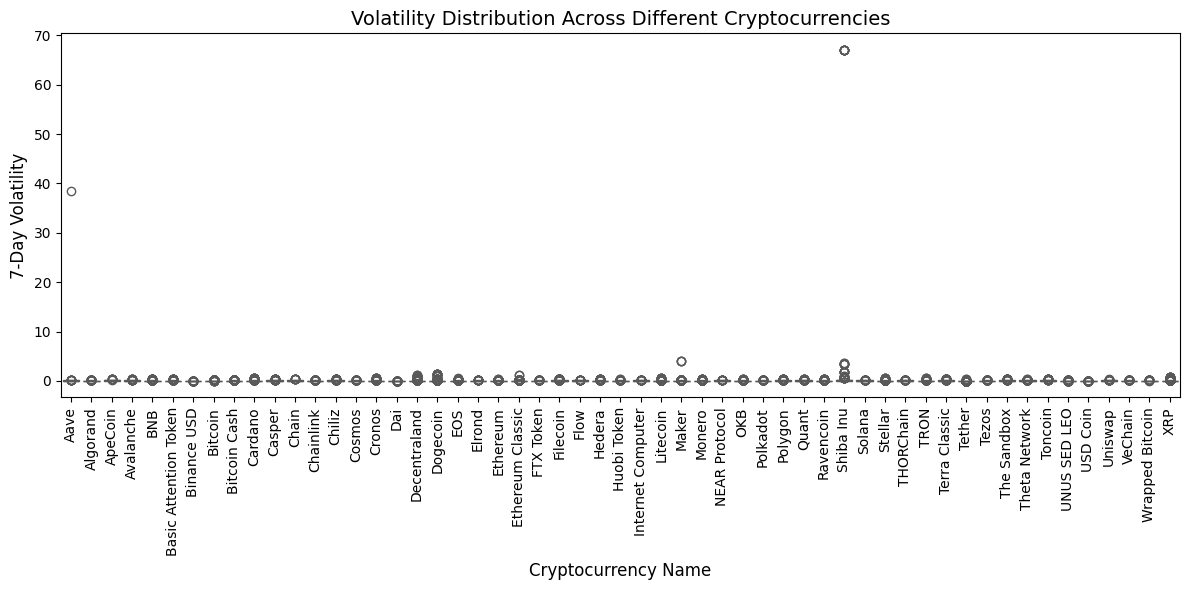

In [125]:
plt.figure(figsize=(12,6))
sns.boxplot(x='crypto_name', y='volatility_7d', data = df, palette= 'Set2',)
plt.title('Volatility Distribution Across Different Cryptocurrencies', fontsize=14)
plt.xlabel('Cryptocurrency Name', fontsize=12)
plt.ylabel('7-Day Volatility', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

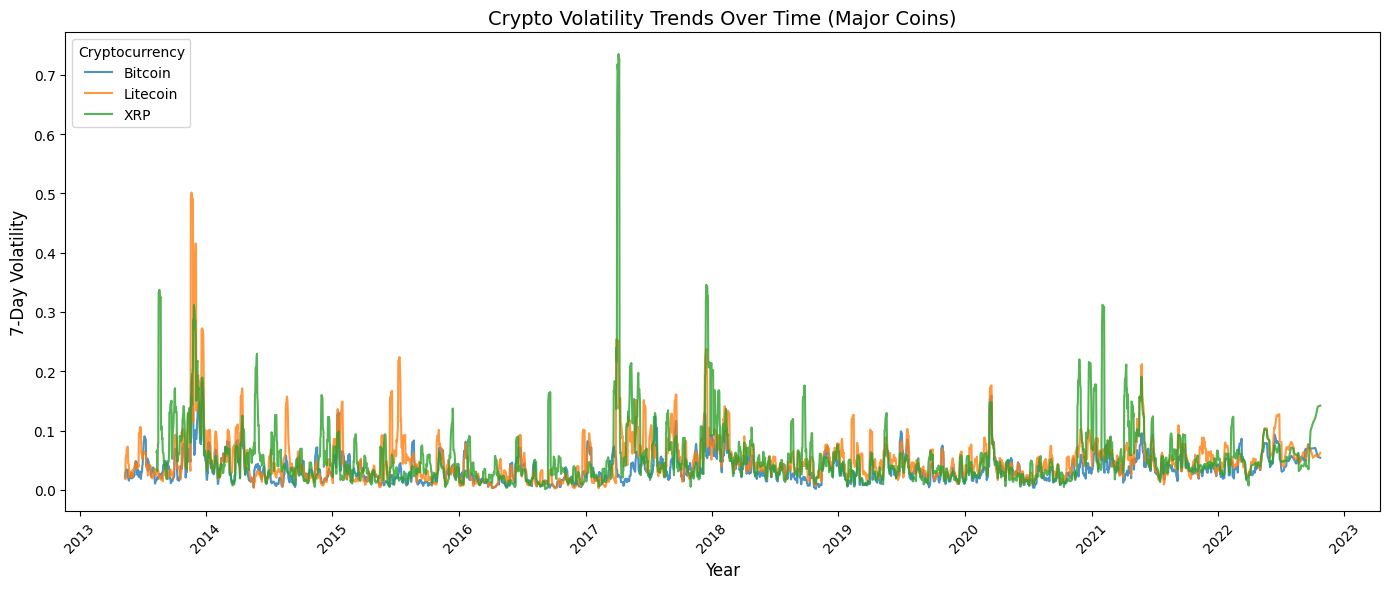

In [126]:
# Time-Series Analysis: Volatility over Time (For the top coins)
plt.figure(figsize=(14,6))

top_coins = df['crypto_name'].value_counts().index[:3]
df_filtered = df[df['crypto_name'].isin(top_coins)]

sns.lineplot(x='date', y='volatility_7d', hue='crypto_name', data=df_filtered, alpha=0.8)
plt.title('Crypto Volatility Trends Over Time (Major Coins)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('7-Day Volatility', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Cryptocurrency', loc='upper left')
plt.tight_layout()
plt.show()

In [127]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 3 : Feature Engineering  

In [131]:
# 0. Sabse pehle data ko crypto_name aur date ke hisab se sort kar lete hain
df_cleaned = df_cleaned.sort_values(by=['crypto_name', 'date']).reset_index(drop=True)

In [132]:
# 1. LIQUIDITY RATIO
# Volume ko Market Cap se divide karenge (1e-8 add kiya hai taaki zero se division na ho)
df_cleaned['liquidity_ratio'] = df_cleaned['volume'] / (df_cleaned['marketCap'] + 1e-8)

In [133]:
# 2. MOVING AVERAGES (7-day & 21-day)
# Har crypto ke liye alag se rolling mean nikalenge
df_cleaned['sma_7'] = df_cleaned.groupby('crypto_name')['close'].transform(lambda x: x.rolling(window=7).mean())
df_cleaned['sma_21'] = df_cleaned.groupby('crypto_name')['close'].transform(lambda x: x.rolling(window=21).mean())

In [134]:
# 3. ROLLING VOLATILITY (Humara Target Feature)
df_cleaned['rolling_volatility_7'] = df_cleaned.groupby('crypto_name')['close'].transform(lambda x: x.rolling(window=7).std())

In [135]:
# 4. BOLLINGER BANDS (20-day window)
df_cleaned['sma_20'] = df_cleaned.groupby('crypto_name')['close'].transform(lambda x: x.rolling(window=20).mean())
df_cleaned['std_20'] = df_cleaned.groupby('crypto_name')['close'].transform(lambda x: x.rolling(window=20).std())

df_cleaned['bollinger_upper'] = df_cleaned['sma_20'] + (2 * df_cleaned['std_20'])
df_cleaned['bollinger_lower'] = df_cleaned['sma_20'] - (2 * df_cleaned['std_20'])

In [136]:
# 5. AVERAGE TRUE RANGE (ATR - 14-day)
# ATR nikalne ke liye pehle True Range (TR) calculate karna hota hai
df_cleaned['prev_close'] = df_cleaned.groupby('crypto_name')['close'].shift(1)
df_cleaned['tr1'] = df_cleaned['high'] - df_cleaned['low']
df_cleaned['tr2'] = (df_cleaned['high'] - df_cleaned['prev_close']).abs()
df_cleaned['tr3'] = (df_cleaned['low'] - df_cleaned['prev_close']).abs()

df_cleaned['true_range'] = df_cleaned[['tr1', 'tr2', 'tr3']].max(axis=1)
df_cleaned['atr_14'] = df_cleaned.groupby('crypto_name')['true_range'].transform(lambda x: x.rolling(window=14).mean())

In [137]:
# 6. CLEANUP: Temporary columns aur rolling ki wajah se bani NaN values ko hatana
# Kyunki rolling window (jaise 21 days) ki shuruat me kuch rows blank (NaN) ho jati hain
df_features = df_cleaned.drop(columns=['prev_close', 'tr1', 'tr2', 'tr3', 'true_range'])
df_features = df_features.dropna().reset_index(drop=True)

print("Feature Engineering Completed Successfully!")
print(f"New Data Shape: {df_features.shape}")
df_features.head()

Feature Engineering Completed Successfully!
New Data Shape: (71845, 17)


,open,high,low,close,volume,marketCap,crypto_name,date,liquidity_ratio,sma_7,sma_21,rolling_volatility_7,sma_20,std_20,bollinger_upper,bollinger_lower,atr_14
0,0.000520,0.000246,0.000505,0.000563,0.000156,0.000316,Aave,2020-10-22,0.493904,0.000556,0.000629,0.000049,0.000661,0.000099,0.000858,0.000463,0.000360
1,0.000559,0.000262,0.000556,0.000617,0.000217,0.000349,Aave,2020-10-23,0.620645,0.000561,0.000658,0.000053,0.000652,0.000095,0.000841,0.000463,0.000356
2,0.000617,0.000262,0.000583,0.000584,0.000164,0.000331,Aave,2020-10-24,0.496955,0.000557,0.000649,0.000050,0.000642,0.000091,0.000824,0.000461,0.000354
3,0.000584,0.000252,0.000566,0.000561,0.000125,0.000318,Aave,2020-10-25,0.394480,0.000551,0.000638,0.000046,0.000631,0.000086,0.000802,0.000460,0.000349
4,0.000561,0.000241,0.000528,0.000533,0.000143,0.000302,Aave,2020-10-26,0.474762,0.000551,0.000626,0.000046,0.000626,0.000088,0.000803,0.000449,0.000343


## Step 4 : Model Training & Evaluation

In [138]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Preparing data for training...")

Preparing data for training...


In [139]:
# 1. Features (X) aur Target (y) define karte hain
# 'crypto_name' aur 'date' ko hata denge kyunki wo non-numerical/identifiers hain
# 'rolling_volatility_7' humara target hai, toh use X se drop karenge
X = df_features.drop(columns=['crypto_name', 'date', 'rolling_volatility_7'])
y = df_features['rolling_volatility_7']

In [142]:
# 2. Data ko Train aur Test sets me split karte hain (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print("\nTraining the Random Forest Model...")

Training set size: (57476, 14)
Testing set size: (14369, 14)

Training the Random Forest Model...


In [143]:
# 3. Model initialize aur train karte hain
# n_jobs=-1 se aapka laptop saare CPU cores use karega taaki training fast ho
model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print("Model Training Completed!")

Model Training Completed!


In [144]:
# 4. Predictions nikalte hain
y_pred = model.predict(X_test)

In [145]:
# 5. Model Evaluation (Project requirement ke mutabik Metrics)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Performance Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
print(f"R² Score (Accuracy/Variance Explained): {r2:.4f}")


--- Model Performance Metrics ---
Mean Absolute Error (MAE): 0.000117
Root Mean Squared Error (RMSE): 0.000868
R² Score (Accuracy/Variance Explained): 0.9482


In [146]:
import joblib

# Model aur Scaler ko .pkl files me save kar rahe hain
joblib.dump(model, 'crypto_volatility_model.pkl')
joblib.dump(scaler, 'crypto_scaler.pkl')

print("Model and Scaler saved successfully as .pkl files!")

Model and Scaler saved successfully as .pkl files!
